# PANDAS - Manipulación de Datos con Python

**Por Álvaro Mena Monge**
Ultima actualización: 24 de febrero del 2026

Biblioteca diseñada para la manipulación y el análisis de datos

Presenta la información en un formato de tabla.
## Conceptos claves
**Series**: objeto unidimensional (similar a un arreglo - 1D) que puede contener varios tipos de datos, como números, cadenas de texto o fechas

**DataFrame**: tabla bidimensional - 2D, similar a una hoja de cálculo

Referencias

Winchester, C. (2021). Pandas cheat sheet [Notebook Jupyter]. GitHub. https://github.com/cjwinchester/pandas-cheat-sheet/blob/master/Pandas%20cheat%20sheet.ipynb

# Importar Pandas

In [1]:
import numpy as np  # Importar estándar de la librería NumPy
import pandas as pd  # Importar estándar de la librería Pandas
pd.__version__

'2.2.2'

# Acceder al archivo mlb.csv

Antes de ejecutar esta celda, sube el archivo **mlb.csv** al panel de archivos de Colab (ícono de carpeta, botón de subir).

In [ ]:
# Ruta al archivo (está en la carpeta /content de Colab)
path = "mlb.csv"

# Creación de un dataframe desde un CSV

Importar un CSV con los salarios de los jugadores de la Liga Mayor de Béisbol en el día inaugural

In [6]:
mlb = pd.read_csv(path) # el médodo read_csv() carga los datos en un

# Consulta de datos
Al cargar los datos por primera vez, conviene hacerse una idea de su contenido. Un dataframe de Pandas ofrece varias funciones útiles para una lectura rápida de los datos:

* **head**(): Muestra los primeros 5 registros del dataframe
(opcionalmente, si desea ver un número diferente, puede introducir un número).
* **tail**(): Igual que head(), pero extrae los registros del final del dataframe.
* **sample**(n) muestra n filas de datos; solo tiene que introducir un número.
* **info**() muestra los valores no nulos en cada columna; es útil para ver si alguna columna tiene valores nulos.
* **describe**() calcula estadísticas resumidas para columnas numéricas.
* **columns** muestra los nombres de las columnas.
* **dtypes** muestra los tipos de datos de cada columna.
* **shape** muestra elnúmero de filas, número de columnas).



In [7]:
mlb.head()

,NAME,TEAM,POS,SALARY,START_YEAR,END_YEAR,YEARS
0,Clayton Kershaw,LAD,SP,33000000,2014,2020,7
1,Zack Greinke,ARI,SP,31876966,2016,2021,6
2,David Price,BOS,SP,30000000,2016,2022,7
3,Miguel Cabrera,DET,1B,28000000,2014,2023,10
4,Justin Verlander,DET,SP,28000000,2013,2019,7


In [ ]:
mlb.head()

,NAME,TEAM,POS,SALARY,START_YEAR,END_YEAR,YEARS
0,Clayton Kershaw,LAD,SP,33000000,2014,2020,7
1,Zack Greinke,ARI,SP,31876966,2016,2021,6
2,David Price,BOS,SP,30000000,2016,2022,7
3,Miguel Cabrera,DET,1B,28000000,2014,2023,10
4,Justin Verlander,DET,SP,28000000,2013,2019,7


In [8]:
mlb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 868 entries, 0 to 867
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   NAME        868 non-null    object
 1   TEAM        868 non-null    object
 2   POS         868 non-null    object
 3   SALARY      868 non-null    int64 
 4   START_YEAR  868 non-null    int64 
 5   END_YEAR    868 non-null    int64 
 6   YEARS       868 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 47.6+ KB


In [10]:
# Configuración para usar espacio como separador de miles y 2 decimales
pd.options.display.float_format = lambda x: '{:,.2f}'.format(x).replace(',', ' ')
mlb.describe()

,SALARY,START_YEAR,END_YEAR,YEARS
count,868.00,868.00,868.00,868.00
mean,4 468 069.18,2 016.49,2 017.43,1.94
std,5 948 459.31,1.21,1.16,1.92
min,535 000.00,2 008.00,2 015.00,1.00
25%,545 500.00,2 017.00,2 017.00,1.00
50%,1 562 500.00,2 017.00,2 017.00,1.00
75%,6 000 000.00,2 017.00,2 017.00,2.00
max,33 000 000.00,2 017.00,2 027.00,13.00


# Selección de una sola columna de datos
Se emplean dos notaciones

mlb.SALARY si el nombre de columna no tiene espacios
mlb['SALARY'] notación de paréntesis cuadrados

Al seleccionar una columna retornará una Series



In [11]:
# seleccionar una columna de los datos
equipos = mlb.TEAM # es lo mismo equipos = mlb['TEAM']

equipos.head()

,TEAM
0,LAD
1,ARI
2,BOS
3,DET
4,DET


In [ ]:
type(equipos)

pandas.core.series.Series

In [12]:
# seleccionar múltiples columnas de datos
salarios_y_nombres = mlb[['SALARY', 'NAME']]
salarios_y_nombres.head()

,SALARY,NAME
0,33000000,Clayton Kershaw
1,31876966,Zack Greinke
2,30000000,David Price
3,28000000,Miguel Cabrera
4,28000000,Justin Verlander


In [ ]:
type(salarios_y_nombres)

# Obtener los valores únicos en una columna


In [13]:
mlb.POS.unique()


array(['SP', '1B', 'RF', '2B', 'DH', 'CF', 'C', 'LF', '3B', 'SS', 'OF',
       'RP', 'P'], dtype=object)

In [ ]:
sorted(mlb.POS.unique()) #ordenar los valores alfabéticamente

['1B', '2B', '3B', 'C', 'CF', 'DH', 'LF', 'OF', 'P', 'RF', 'RP', 'SP', 'SS']

Para obtener una lista de equipos de la MLB y la cantidad de veces que cada uno aparece en nuestros datos salariales (en otras palabras, el número de jugadores en la lista de cada equipo), podríamos hacer lo siguiente:

In [14]:
mlb.TEAM.value_counts()

,count
TEAM,
TEX,34
COL,32
TB,32
CIN,31
NYM,31
LAD,31
SEA,31
SD,31
BOS,31


Ejecución de estadísticas de resumen básicas, una por una:

* suma()
* media()
* mediana()
* máx()
* mín()

In [15]:
promedio = mlb.SALARY.mean()

resultado_formateado = f"{promedio:,.2f}"

print(resultado_formateado)

4,468,069.18


# Adición de una columna calculada al dataframe


In [16]:
mlb['CONTRACT_TOTAL'] = mlb['SALARY'] * mlb['YEARS']
mlb.head()

,NAME,TEAM,POS,SALARY,START_YEAR,END_YEAR,YEARS,CONTRACT_TOTAL
0,Clayton Kershaw,LAD,SP,33000000,2014,2020,7,231000000
1,Zack Greinke,ARI,SP,31876966,2016,2021,6,191261796
2,David Price,BOS,SP,30000000,2016,2022,7,210000000
3,Miguel Cabrera,DET,1B,28000000,2014,2023,10,280000000
4,Justin Verlander,DET,SP,28000000,2013,2019,7,196000000


### Distribución de Salarios de Jugadores

Este histograma ilustra la distribución general de los salarios de los jugadores en el conjunto de datos, mostrando los rangos de salario más comunes.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.histplot(mlb['SALARY'], bins=30, kde=True, palette='viridis')
plt.title('Distribución de Salarios de Jugadores de MLB')
plt.xlabel('Salario')
plt.ylabel('Número de Jugadores')
plt.ticklabel_format(style='plain', axis='x') # Para evitar la notación científica en el eje x
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Salario Promedio por Equipo

Este gráfico de barras mostrará el salario promedio de los jugadores de cada equipo de la MLB, permitiéndonos identificar qué equipos invierten más en sus plantillas.

/tmp/ipython-input-1075425979.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salario_promedio_por_equipo.index, y=salario_promedio_por_equipo.values, palette='viridis')


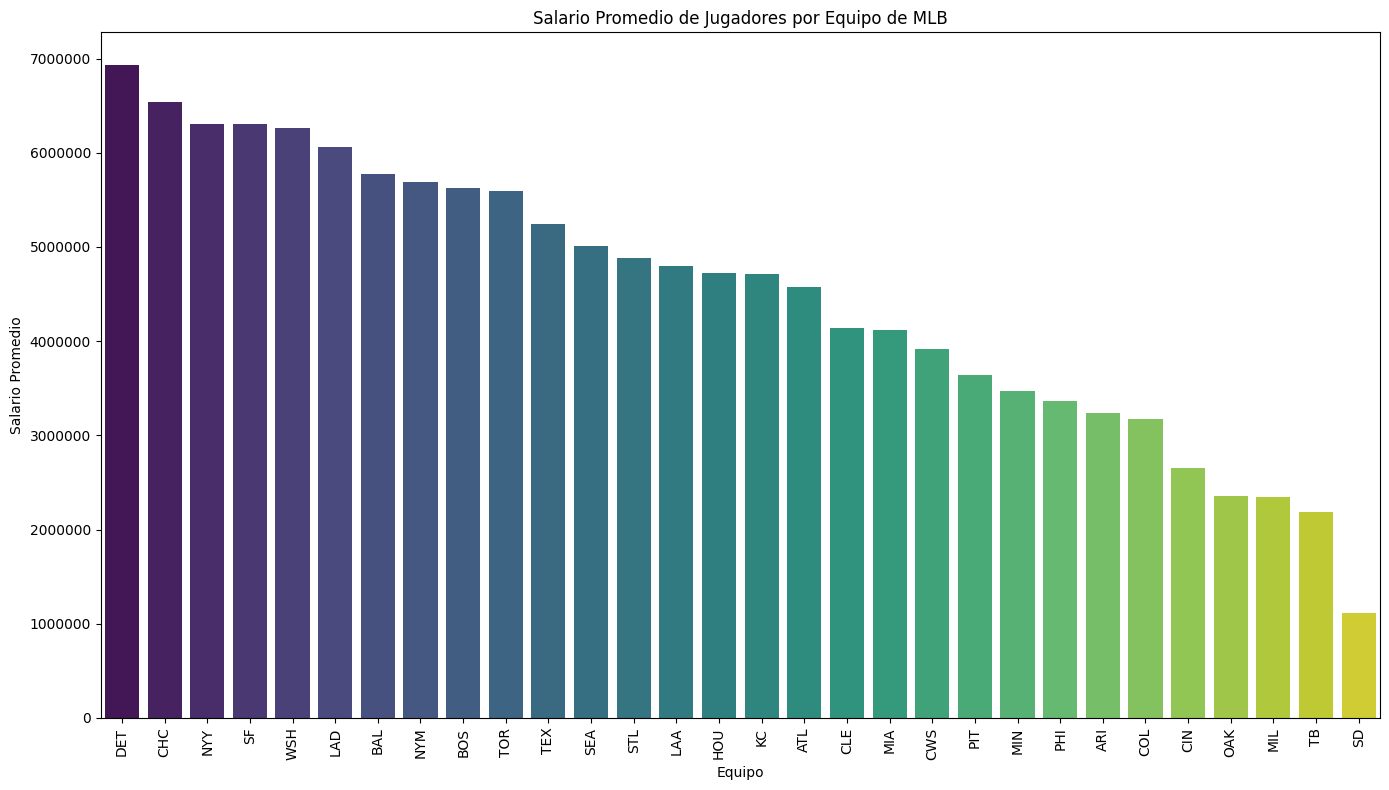

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el salario promedio por equipo
salario_promedio_por_equipo = mlb.groupby('TEAM')['SALARY'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x=salario_promedio_por_equipo.index, y=salario_promedio_por_equipo.values, palette='viridis')
plt.title('Salario Promedio de Jugadores por Equipo de MLB')
plt.xlabel('Equipo')
plt.ylabel('Salario Promedio')
plt.xticks(rotation=90) # Rotar las etiquetas del eje x para mejor legibilidad
plt.ticklabel_format(style='plain', axis='y') # Para evitar la notación científica en el eje y
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se superpongan
plt.show()